In [1]:
import kagglehub
from pathlib import Path
import pandas as pd

# Download dataset from Kaggle
path = Path(kagglehub.dataset_download("yasserh/wine-quality-dataset"))
csv_path = next(path.rglob("*.csv"))
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip().str.replace(" ", "_")

if "Id" in df.columns:
    df = df.drop(columns=["Id"])

X = df.drop(columns=["quality"])
y = df[["quality"]]

print("Path to dataset files:", path)
print("Using CSV:", csv_path.name)
print(df.shape)
print(df.head())


Path to dataset files: /Users/brandongao/.cache/kagglehub/datasets/yasserh/wine-quality-dataset/versions/1
Using CSV: WineQT.csv
(1143, 12)
   fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free_sulfur_dioxide  total_sulfur_dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.

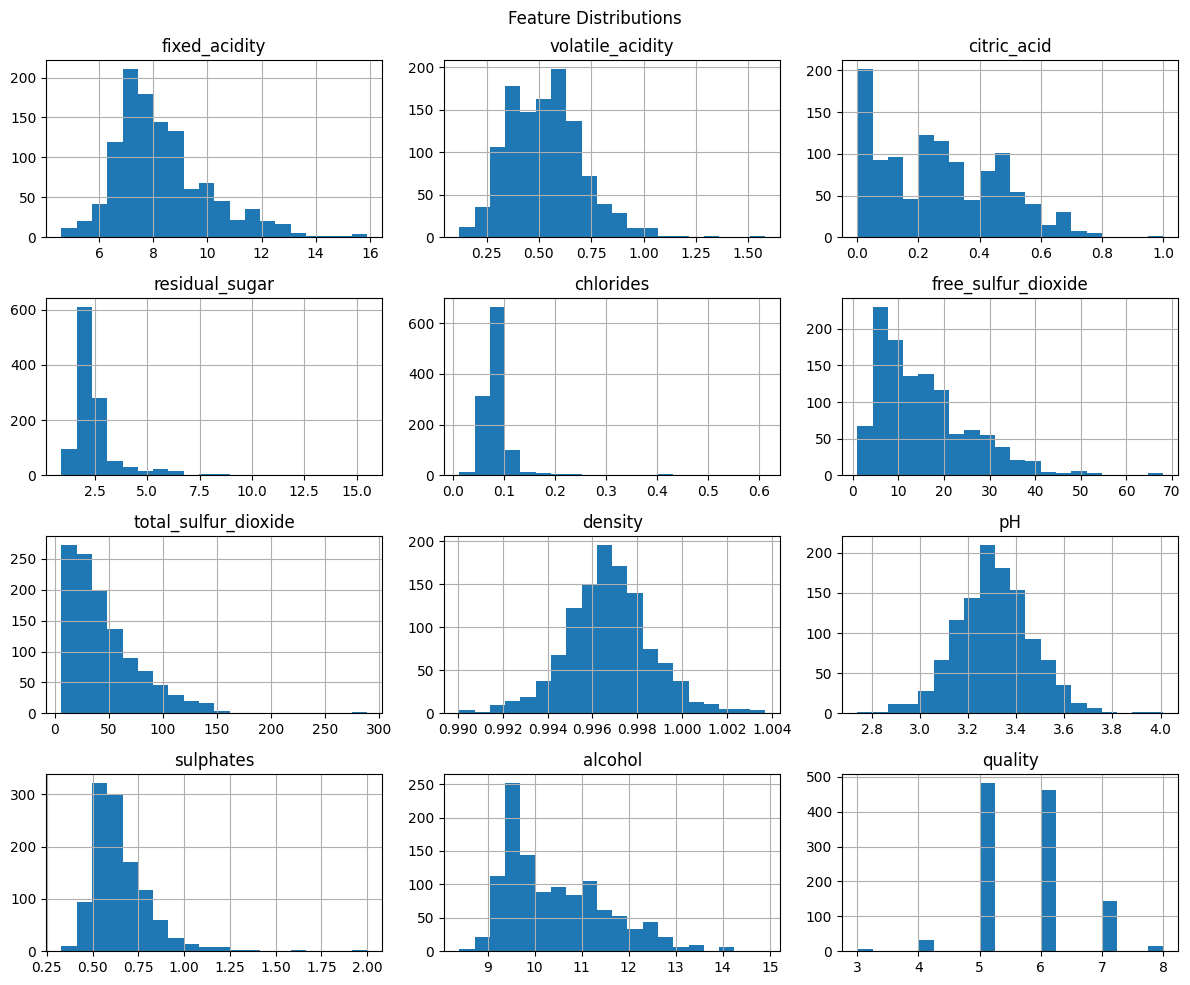

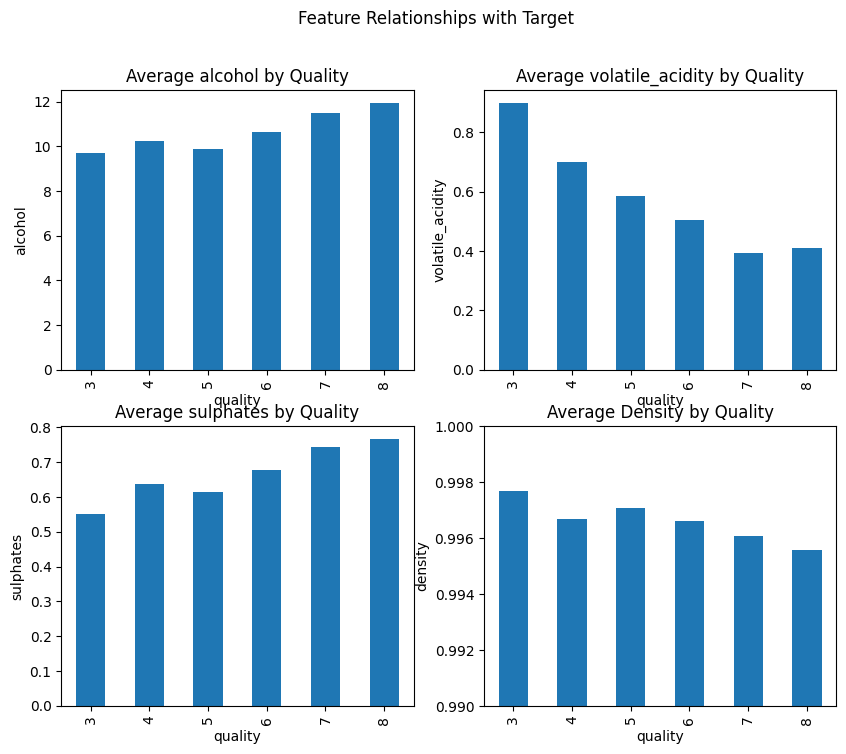

<Figure size 640x480 with 0 Axes>

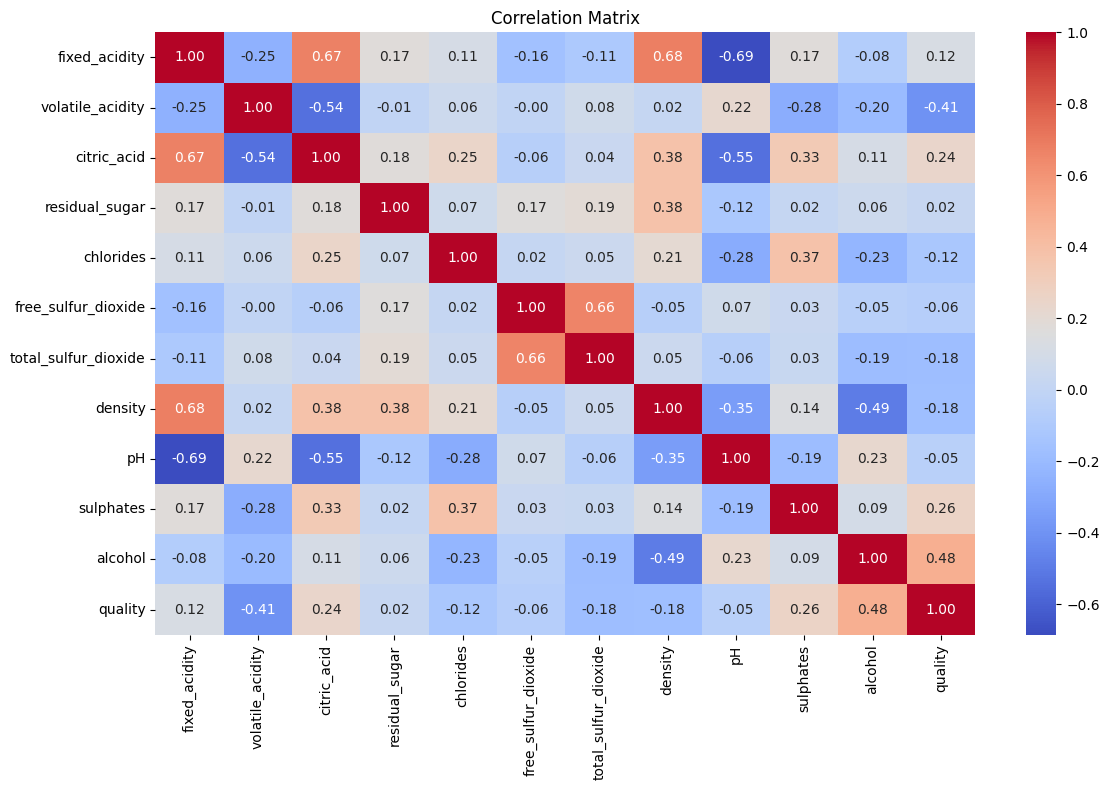

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# df
assert "df" in globals(), "Run the data-loading cell above first."

# 1. histogram
df.hist(figsize=(12, 10), bins=20)
plt.suptitle('Feature Distributions')
plt.tight_layout()
plt.show()

# 2. bar plot - relationships with target
important = ['alcohol', 'volatile_acidity', 'sulphates', 'density']
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()
for i, feature in enumerate(important):
    df.groupby('quality')[feature].mean().plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Average {feature} by Quality')
    axes[i].set_xlabel('quality')
    axes[i].set_ylabel(feature)
plt.suptitle('Feature Relationships with Target')
# just for density, zoom in on the y axis
df.groupby('quality')['density'].mean().plot(kind='bar')
plt.title('Average Density by Quality')
plt.ylim(0.99, 1.00)  # zoom in
plt.show()
plt.tight_layout()
plt.show()

# 3. correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

Cluster profile (means):
          alcohol  volatile_acidity  sulphates  density  quality
cluster                                                        
0           9.83              0.62       0.57     1.00     5.27
1          11.83              0.46       0.67     0.99     6.22
2          10.27              0.43       0.83     1.00     5.90


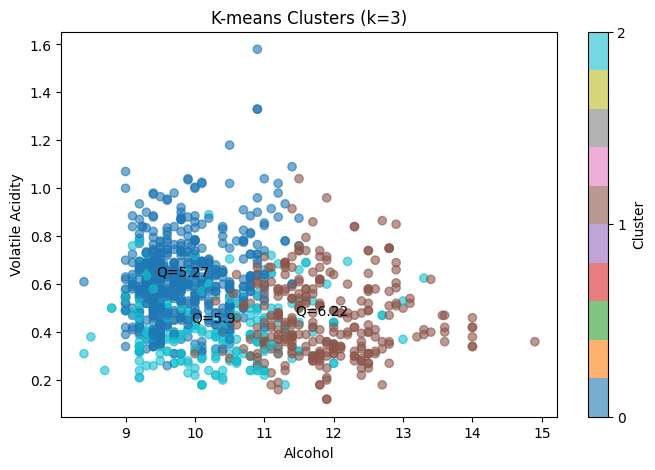

In [3]:
# Import libraries
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# Fill missing values
df.fillna(df.median(), inplace=True)

# Use the 4 features from your EDA
features = ['alcohol', 'volatile_acidity', 'sulphates', 'density']
X_km = df[features]

# Scale the features
scaler = StandardScaler()
X_km_scaled = scaler.fit_transform(X_km)

# Fit K-means with k=3 
# 42 for hitchhikers guide to the galaxy :)
km = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = km.fit_predict(X_km_scaled)

# give each cluster stats
profile = df.groupby('cluster')[['alcohol', 'volatile_acidity', 'sulphates', 'density', 'quality']].mean().round(2)
print("Cluster profile (means):\n", profile)


# give each cluster color
plt.figure(figsize=(8, 5))
scatter = plt.scatter(df['alcohol'], df['volatile_acidity'],c=df['cluster'], cmap='tab10', alpha=0.6)
plt.colorbar(scatter, label='Cluster', ticks=[0, 1, 2])
plt.xlabel('Alcohol')
plt.ylabel('Volatile Acidity')
plt.title('K-means Clusters (k=3)')

for cluster_id, row in profile.iterrows():
    plt.text(row['alcohol'], row['volatile_acidity'],
             f"Q={row['quality']}", fontsize=10, 
             ha='center', va='bottom', color='black')

plt.show()

,k,train_acc,val_acc,train_precision,train_recall,val_precision,val_recall
0,1,1.000000,0.829694,1.000000,1.000000,0.821229,0.829694
1,3,0.890511,0.799127,0.879799,0.890511,0.769866,0.799127
2,5,0.862774,0.825328,0.856739,0.862774,0.785118,0.825328
3,7,0.861314,0.842795,0.819328,0.861314,0.804459,0.842795
4,9,0.848175,0.829694,0.800973,0.848175,0.788114,0.829694
5,11,0.842336,0.838428,0.791508,0.842336,0.799087,0.838428


,k,train_acc,val_acc,train_precision,train_recall,val_precision,val_recall
0,1,1.000000,0.820961,1.000000,1.000000,0.814787,0.820961
1,3,0.891971,0.794760,0.884293,0.891971,0.766973,0.794760
2,5,0.871533,0.825328,0.851458,0.871533,0.788972,0.825328
3,7,0.861314,0.842795,0.819422,0.861314,0.804459,0.842795
4,9,0.858394,0.847162,0.815430,0.858394,0.809592,0.847162
5,11,0.846715,0.838428,0.799664,0.846715,0.799612,0.838428


,k,train_acc,val_acc,train_precision,train_recall,val_precision,val_recall
0,1,1.000000,0.820961,1.000000,1.000000,0.814588,0.820961
1,3,0.905109,0.816594,0.899318,0.905109,0.777596,0.816594
2,5,0.867153,0.834061,0.828675,0.867153,0.799392,0.834061
3,7,0.864234,0.838428,0.823336,0.864234,0.800465,0.838428
4,9,0.855474,0.838428,0.812069,0.855474,0.799612,0.838428
5,11,0.852555,0.851528,0.807391,0.852555,0.815107,0.851528


,k,train_acc,val_acc,train_precision,train_recall,val_precision,val_recall
0,1,1.000000,0.829694,1.000000,1.000000,0.812308,0.829694
1,3,0.900730,0.820961,0.892005,0.900730,0.783332,0.820961
2,5,0.872993,0.838428,0.858701,0.872993,0.803032,0.838428
3,7,0.858394,0.825328,0.815982,0.858394,0.786952,0.825328
4,9,0.856934,0.834061,0.814122,0.856934,0.794788,0.834061
5,11,0.848175,0.820961,0.800765,0.848175,0.776167,0.820961


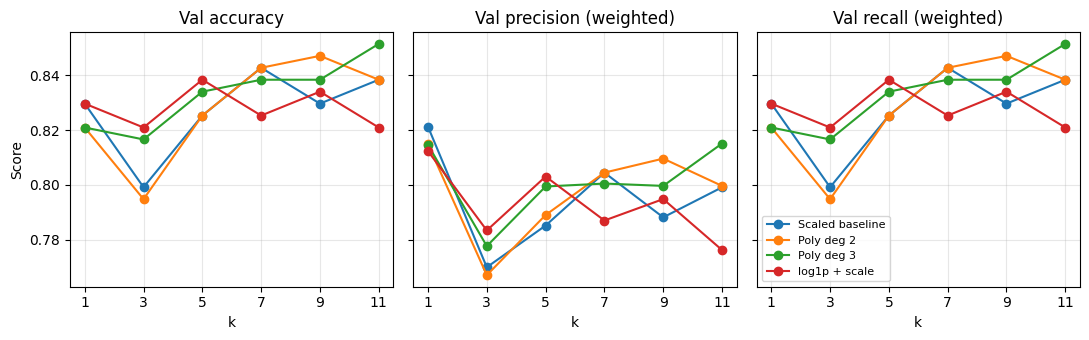

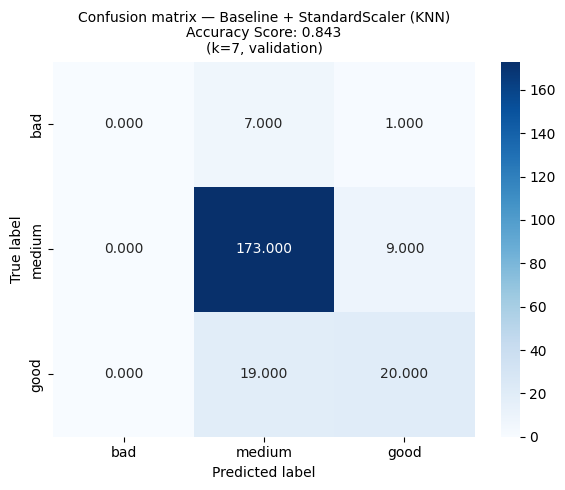

In [4]:

import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import precision_score, recall_score, confusion_matrix, accuracy_score
import seaborn as sns

# Three quality buckets: bad (<5), medium ([5,7)), good (>=7)
y_bucket = np.select(
    [
        df["quality"].values < 5,
        (df["quality"].values >= 5) & (df["quality"].values < 7),
        df["quality"].values >= 7,
    ],
    [0, 1, 2],
    default=-1,
)

feature_cols = [
    "fixed_acidity","volatile_acidity","citric_acid","residual_sugar","chlorides","free_sulfur_dioxide","total_sulfur_dioxide","density","pH","sulphates","alcohol",
]
X = df[feature_cols]

# 60% train / 20% validation / 20% test
X_temp, X_test_unused, y_temp, y_test_unused = train_test_split(X, y_bucket, test_size=0.2,random_state=42,)
X_train, X_val, y_train, y_val = train_test_split(X_temp,y_temp,test_size=0.25,random_state=42,)

X_train = np.asarray(X_train, dtype=float)
X_val = np.asarray(X_val, dtype=float)

k_values = [1, 3, 5, 7, 9, 11]
# choose these odd values to prevent ties and i wanted 6 evenly spaced off values from very local/ flexible to a more structured/smooth model by the end which would test high bias/low variance ( stopped at 11 because there were only 11 features)

# Baseline: original features + StandardScaler (preprocessing)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

knn_results = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, weights="uniform")
    knn.fit(X_train_scaled, y_train)
    knn_results.append({
        "k": k,"train_acc": knn.score(X_train_scaled, y_train),"val_acc": knn.score(X_val_scaled, y_val),
        "train_precision": precision_score(y_train, knn.predict(X_train_scaled), average="weighted", zero_division=0),
        "train_recall": recall_score(y_train, knn.predict(X_train_scaled), average="weighted", zero_division=0),
        "val_precision": precision_score(y_val, knn.predict(X_val_scaled), average="weighted", zero_division=0),
        "val_recall": recall_score(y_val, knn.predict(X_val_scaled), average="weighted", zero_division=0),
    })

# Polynomial degree 2: squared, then scale for KNN. Degree 2 adds squares and is a more complex model class, I wanted to test it out to see if pattern was better than the linear one
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_val_poly = poly.transform(X_val)

scaler_poly = StandardScaler()
X_train_poly2_scaled = scaler_poly.fit_transform(X_train_poly)
X_val_poly2_scaled = scaler_poly.transform(X_val_poly)

knn_results_poly = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_poly2_scaled, y_train)
    knn_results_poly.append({
        "k": k,"train_acc": knn.score(X_train_poly2_scaled, y_train),"val_acc": knn.score(X_val_poly2_scaled, y_val),
        "train_precision": precision_score(y_train, knn.predict(X_train_poly2_scaled), average="weighted", zero_division=0),
        "train_recall": recall_score(y_train, knn.predict(X_train_poly2_scaled), average="weighted", zero_division=0),
        "val_precision": precision_score(y_val, knn.predict(X_val_poly2_scaled), average="weighted", zero_division=0),
        "val_recall": recall_score(y_val, knn.predict(X_val_poly2_scaled), average="weighted", zero_division=0),
    })

# Polynomial degree 3: degree 2 helped out a little bit in some of the features so I tried 3rd degree to compensate for the fact that there were 11 features and probably needed a higher order to map correctly
poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly3 = poly3.fit_transform(X_train)
X_val_poly3 = poly3.transform(X_val)

scaler_poly3 = StandardScaler()
X_train_poly3_scaled = scaler_poly3.fit_transform(X_train_poly3)
X_val_poly3_scaled = scaler_poly3.transform(X_val_poly3)

knn_results_poly3 = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_poly3_scaled, y_train)
    knn_results_poly3.append({
        "k": k,"train_acc": knn.score(X_train_poly3_scaled, y_train),"val_acc": knn.score(X_val_poly3_scaled, y_val),
        "train_precision": precision_score(y_train, knn.predict(X_train_poly3_scaled), average="weighted", zero_division=0),
        "train_recall": recall_score(y_train, knn.predict(X_train_poly3_scaled), average="weighted", zero_division=0),
        "val_precision": precision_score(y_val, knn.predict(X_val_poly3_scaled), average="weighted", zero_division=0),
        "val_recall": recall_score(y_val, knn.predict(X_val_poly3_scaled), average="weighted", zero_division=0),
    })

# Log transformation: a lot of the inputs are right skewed, the log will help compress larger values making it less sensitive to outliers.
X_train_log = np.log1p(np.maximum(X_train, 0.0))
X_val_log = np.log1p(np.maximum(X_val, 0.0))

scaler_log = StandardScaler()
X_train_log_scaled = scaler_log.fit_transform(X_train_log)
X_val_log_scaled = scaler_log.transform(X_val_log)

knn_results_log = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_log_scaled, y_train)
    knn_results_log.append({
        "k": k,"train_acc": knn.score(X_train_log_scaled, y_train),"val_acc": knn.score(X_val_log_scaled, y_val),
        "train_precision": precision_score(y_train, knn.predict(X_train_log_scaled), average="weighted", zero_division=0),
        "train_recall": recall_score(y_train, knn.predict(X_train_log_scaled), average="weighted", zero_division=0),
        "val_precision": precision_score(y_val, knn.predict(X_val_log_scaled), average="weighted", zero_division=0),
        "val_recall": recall_score(y_val, knn.predict(X_val_log_scaled), average="weighted", zero_division=0),
    })

display(pd.DataFrame(knn_results))
display(pd.DataFrame(knn_results_poly))
display(pd.DataFrame(knn_results_poly3))
display(pd.DataFrame(knn_results_log))

transformations = [
    ("Scaled baseline", knn_results),
    ("Poly deg 2", knn_results_poly),
    ("Poly deg 3", knn_results_poly3),
    ("log1p + scale", knn_results_log),
]

fig, axes = plt.subplots(1, 3, figsize=(11, 3.5), sharey=True)

metrics = [
    (axes[0], "Val accuracy","val_acc"),
    (axes[1], "Val precision (weighted)","val_precision"),
    (axes[2], "Val recall (weighted)","val_recall"),
]

for ax, title, key in metrics:
    for name, rows in transformations:
        ks = [r["k"]  for r in rows]
        scores = [r[key]  for r in rows]
        ax.plot(ks, scores, marker="o", label=name)
    ax.set_title(title)
    ax.set_xlabel("k")
    ax.set_xticks(k_values)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Score")
axes[-1].legend(fontsize=8)

plt.tight_layout()
plt.show()

cm_labels = ["bad", "medium", "good"]

best_k = max(knn_results, key=lambda r: r["val_acc"])["k"]
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)
y_pred = knn_best.predict(X_val_scaled)

cm  = confusion_matrix(y_val, y_pred, labels=[0, 1, 2])
acc = accuracy_score(y_val, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm.astype(float), annot=True, fmt=".3f", cmap="Blues", ax=ax,
    xticklabels=cm_labels, yticklabels=cm_labels, vmin=0,
)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title(
    f"Confusion matrix — Baseline + StandardScaler (KNN)\nAccuracy Score: {acc:.3f}\n(k={best_k}, validation)",
    fontsize=10,
)
plt.tight_layout()
plt.show()


,Model,α,Train MSE,Validation MSE,Train RMSE,Validation RMSE,Train R2,Validation R2
0,Lasso,0.01,0.4173,0.3699,0.6460,0.6082,0.3790,0.3353
1,Ridge,100,0.4172,0.3710,0.6459,0.6091,0.3791,0.3332
2,Ridge,10,0.4151,0.3786,0.6443,0.6153,0.3821,0.3196
3,Ridge,1,0.4151,0.3799,0.6443,0.6163,0.3822,0.3173
4,Ridge,0.5,0.4151,0.3800,0.6443,0.6164,0.3822,0.3172
5,Ridge,0.1,0.4151,0.3800,0.6443,0.6165,0.3822,0.3171
6,Ridge,0.01,0.4151,0.3800,0.6443,0.6165,0.3822,0.3171
7,Linear Regression,none,0.4151,0.3800,0.6443,0.6165,0.3822,0.3171
8,Lasso,0.1,0.4525,0.3821,0.6727,0.6182,0.3265,0.3133
9,Lasso,0.5,0.6719,0.5565,0.8197,0.7460,0.0000,-0.0000


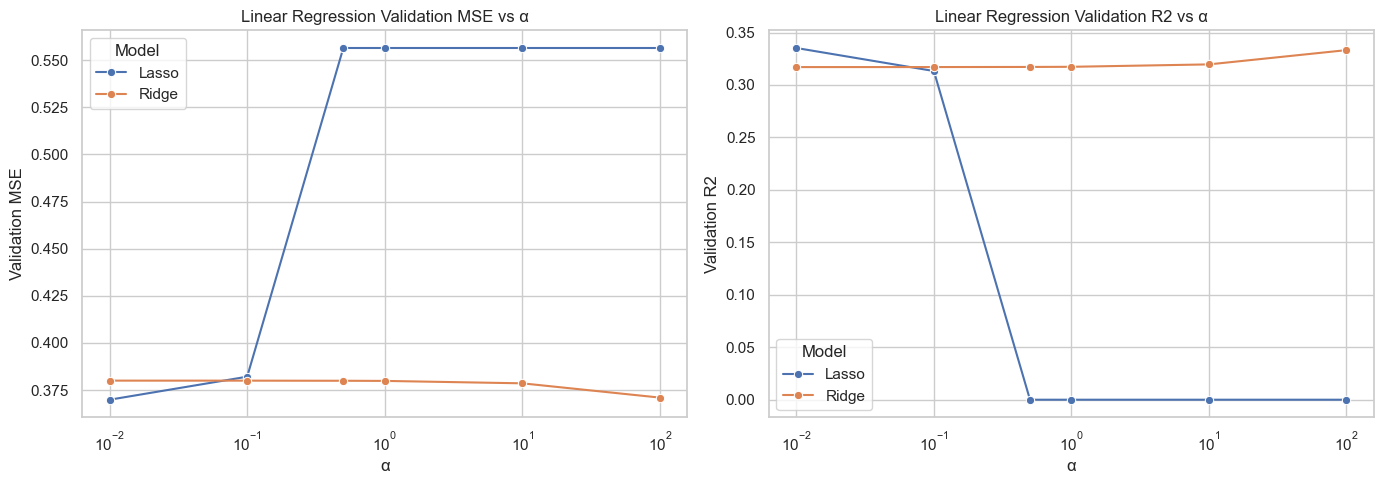

In [5]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid')

# Linear regression summary table
feature_cols_reg = [
    "fixed_acidity", "volatile_acidity", "citric_acid", "residual_sugar","chlorides", "free_sulfur_dioxide", "total_sulfur_dioxide","density", "pH", "sulphates", "alcohol",
]
X_reg = df[feature_cols_reg].astype(float)
y_reg = df["quality"].astype(float)

X_train_reg, X_val_reg, y_train_reg, y_val_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42,
)

reg_scaler = StandardScaler()
X_train_reg_scaled = reg_scaler.fit_transform(X_train_reg)
X_val_reg_scaled = reg_scaler.transform(X_val_reg)

regression_rows = []
alpha_values = [0.01, 0.1, 0.5, 1, 10, 100]

def add_regression_metrics(model_name, alpha_label, model):
    model.fit(X_train_reg_scaled, y_train_reg)
    train_pred = model.predict(X_train_reg_scaled)
    val_pred = model.predict(X_val_reg_scaled)
    regression_rows.append({
        'Model': model_name,'α': alpha_label,'Train MSE': mean_squared_error(y_train_reg, train_pred),  
        'Validation MSE': mean_squared_error(y_val_reg, val_pred),
        'Train RMSE': mean_squared_error(y_train_reg, train_pred) ** 0.5,
        'Validation RMSE': mean_squared_error(y_val_reg, val_pred) ** 0.5,
        'Train R2': r2_score(y_train_reg, train_pred),
        'Validation R2': r2_score(y_val_reg, val_pred),
    })

add_regression_metrics('Linear Regression', 'none', LinearRegression())

for alpha in alpha_values:
    add_regression_metrics('Ridge', alpha, Ridge(alpha=alpha))
    add_regression_metrics('Lasso', alpha, Lasso(alpha=alpha, max_iter=10000))

regression_results = pd.DataFrame(regression_rows)
regression_results = regression_results.sort_values(
    by=['Validation MSE', 'Validation R2'],
    ascending=[True, False],
).reset_index(drop=True)

display(regression_results.round(4))

# Linear regression plots
reg_plot_df = regression_results[regression_results['Model'].isin(['Ridge', 'Lasso'])].copy()
reg_plot_df['α'] = reg_plot_df['α'].astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
sns.lineplot(data=reg_plot_df, x='α', y='Validation MSE', hue='Model', marker='o', ax=axes[0])
sns.lineplot(data=reg_plot_df, x='α', y='Validation R2', hue='Model', marker='o', ax=axes[1])
axes[0].set_title('Linear Regression Validation MSE vs α')
axes[1].set_title('Linear Regression Validation R2 vs α')
for ax in axes:
    ax.set_xscale('log')
    ax.set_xlabel('α')
plt.tight_layout()
plt.show()


/Users/brandongao/Desktop/NYU/ml/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/brandongao/Desktop/NYU/ml/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/brandongao/Desktop/NYU/ml/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=

,Penalty,C,Train Accuracy,Validation Accuracy,Train Precision,Validation Precision,Train Recall,Validation Recall
0,L1,0.01,0.8292,0.7948,0.6876,0.6316,0.8292,0.7948
1,L1,0.10,0.8438,0.8253,0.7989,0.7956,0.8438,0.8253
2,L1,0.50,0.8423,0.8384,0.8285,0.8029,0.8423,0.8384
3,L1,1.00,0.8409,0.8297,0.8094,0.7885,0.8409,0.8297
4,L1,10.00,0.8423,0.8341,0.8122,0.7954,0.8423,0.8341
5,L1,100.00,0.8423,0.8341,0.8122,0.7954,0.8423,0.8341
6,L2,0.01,0.8336,0.7991,0.7988,0.7500,0.8336,0.7991
7,L2,0.10,0.8453,0.8384,0.8324,0.8029,0.8453,0.8384
8,L2,0.50,0.8423,0.8297,0.8113,0.7885,0.8423,0.8297
9,L2,1.00,0.8409,0.8341,0.8099,0.7954,0.8409,0.8341


Best Logistic Regression: L1, C=0.5, validation accuracy=0.838


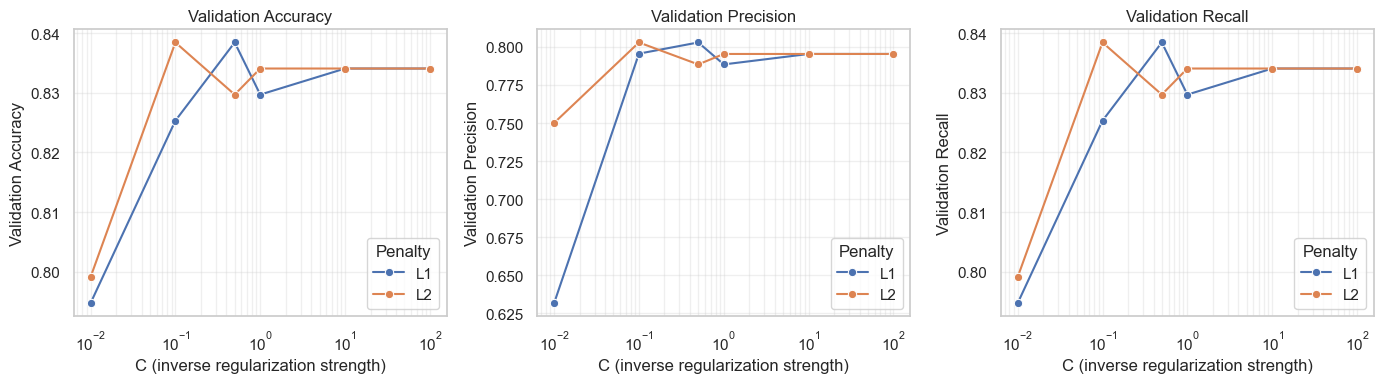

In [6]:
# Logistic regression regularization comparison
from sklearn.linear_model import LogisticRegression

scaler_lr = StandardScaler()
X_train_lr = scaler_lr.fit_transform(X_train)
X_val_lr = scaler_lr.transform(X_val)

C_values = [0.01, 0.1, 0.5, 1.0, 10.0, 100.0]
logistic_rows = []

for penalty_name, penalty_type in [("L1", "l1"), ("L2", "l2")]:
    for C in C_values:
        lr = LogisticRegression(
            C=C,
            penalty=penalty_type,
            solver="saga",
            max_iter=10000,
            random_state=42,
        )
        lr.fit(X_train_lr, y_train)
        train_pred = lr.predict(X_train_lr)
        val_pred = lr.predict(X_val_lr)
        logistic_rows.append({
            "Penalty": penalty_name,
            "C": C,
            "Train Accuracy": lr.score(X_train_lr, y_train),
            "Validation Accuracy": lr.score(X_val_lr, y_val),
            "Train Precision": precision_score(y_train, train_pred, average="weighted", zero_division=0),
            "Validation Precision": precision_score(y_val, val_pred, average="weighted", zero_division=0),
            "Train Recall": recall_score(y_train, train_pred, average="weighted", zero_division=0),
            "Validation Recall": recall_score(y_val, val_pred, average="weighted", zero_division=0),
        })

logistic_results = pd.DataFrame(logistic_rows)
best_logistic = logistic_results.sort_values(
    by=["Validation Accuracy", "Validation Precision", "Validation Recall"],
    ascending=[False, False, False],
).iloc[0]
best_C = best_logistic["C"]
best_penalty = best_logistic["Penalty"]

logistic_results = logistic_results.sort_values(by=["Penalty", "C"]).reset_index(drop=True)

lr_results = logistic_results.rename(
    columns={
        "Train Accuracy": "train_acc",
        "Validation Accuracy": "val_acc",
        "Train Precision": "train_precision",
        "Validation Precision": "val_precision",
        "Train Recall": "train_recall",
        "Validation Recall": "val_recall",
    }
).to_dict("records")

display(logistic_results.round(4))
print(
    f"Best Logistic Regression: {best_penalty}, C={best_C:g}, "
    f"validation accuracy={best_logistic['Validation Accuracy']:.3f}"
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True)
for ax, metric in zip(
    axes,
    ["Validation Accuracy", "Validation Precision", "Validation Recall"],
):
    sns.lineplot(data=logistic_results, x="C", y=metric, hue="Penalty", marker="o", ax=ax)
    ax.set_xscale("log")
    ax.set_title(metric)
    ax.set_xlabel("C (inverse regularization strength)")
    ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()


/Users/brandongao/Desktop/NYU/ml/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/brandongao/Desktop/NYU/ml/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


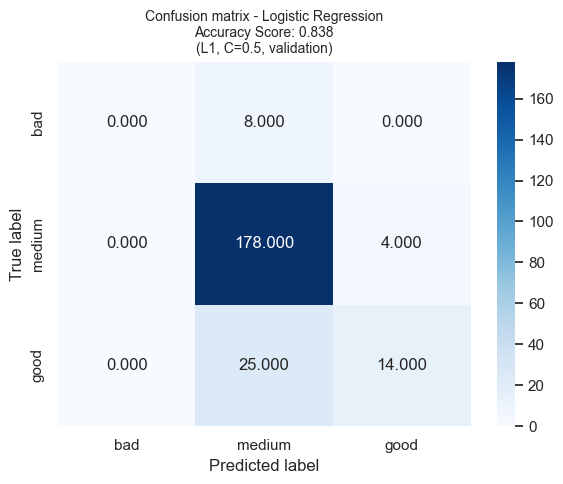

In [7]:
# Confusion matrix for logistic regression, use best C for validation
cm_labels = ["bad", "medium", "good"]

lr_best = LogisticRegression(
    C=best_C,
    penalty="l1" if best_penalty == "L1" else "l2",
    solver="saga",
    max_iter=10000,
    random_state=42,
)
lr_best.fit(X_train_lr, y_train)
y_pred_lr = lr_best.predict(X_val_lr)

cm_lr = confusion_matrix(y_val, y_pred_lr, labels=[0, 1, 2])
acc_lr = accuracy_score(y_val, y_pred_lr)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_lr.astype(float), annot=True, fmt=".3f", cmap="Blues", ax=ax,
    xticklabels=cm_labels, yticklabels=cm_labels, vmin=0,
)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title(
    f"Confusion matrix - Logistic Regression\n"
    f"Accuracy Score: {acc_lr:.3f}\n"
    f"({best_penalty}, C={best_C:g}, validation)",
    fontsize=10,
)
plt.tight_layout()
plt.show()


/Users/brandongao/Desktop/NYU/ml/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/brandongao/Desktop/NYU/ml/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,model,test_accuracy
0,"KNN baseline, k=7",0.8559
1,"Logistic Regression L1, C=0.5",0.8734


,model,test_acc,test_precision,test_recall
0,"KNN baseline, k=7",0.8559,0.8246,0.8559
1,"Logistic Regression L1, C=0.5",0.8734,0.8467,0.8734


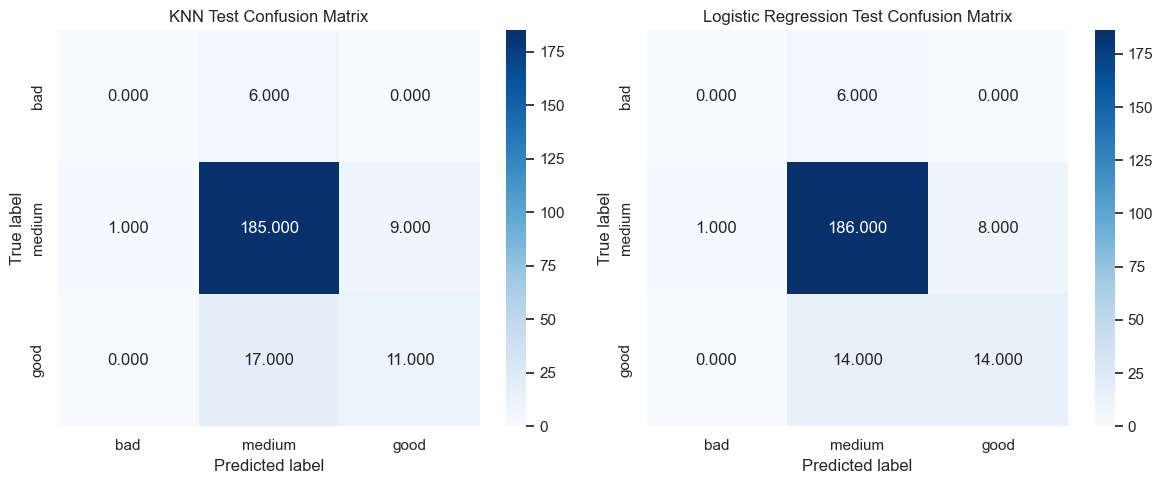

In [8]:
# Final confusion matrices using test
X_train_val_final = np.asarray(X_temp, dtype=float)
X_test_final = np.asarray(X_test_unused, dtype=float)
y_train_val_final = y_temp
y_test_final = y_test_unused

final_scaler = StandardScaler()
X_train_val_scaled = final_scaler.fit_transform(X_train_val_final)
X_test_scaled = final_scaler.transform(X_test_final)

final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_val_scaled, y_train_val_final)
y_test_pred_knn = final_knn.predict(X_test_scaled)

final_lr = LogisticRegression(
    C=best_C,
    penalty="l1" if best_penalty == "L1" else "l2",
    solver="saga",
    max_iter=10000,
    random_state=42,
)
final_lr.fit(X_train_val_scaled, y_train_val_final)
y_test_pred_lr = final_lr.predict(X_test_scaled)

knn_test_acc = accuracy_score(y_test_final, y_test_pred_knn)
lr_test_acc = accuracy_score(y_test_final, y_test_pred_lr)

accuracy_summary = pd.DataFrame([
    {"model": f"KNN baseline, k={best_k}", "test_accuracy": knn_test_acc},
    {"model": f"Logistic Regression {best_penalty}, C={best_C:g}", "test_accuracy": lr_test_acc},
])
display(accuracy_summary.round(4))

generalization_results = pd.DataFrame([
    {
        "model": f"KNN baseline, k={best_k}",
        "test_acc": knn_test_acc,
        "test_precision": precision_score(y_test_final, y_test_pred_knn, average="weighted", zero_division=0),
        "test_recall": recall_score(y_test_final, y_test_pred_knn, average="weighted", zero_division=0),
    },
    {
        "model": f"Logistic Regression {best_penalty}, C={best_C:g}",
        "test_acc": lr_test_acc,
        "test_precision": precision_score(y_test_final, y_test_pred_lr, average="weighted", zero_division=0),
        "test_recall": recall_score(y_test_final, y_test_pred_lr, average="weighted", zero_division=0),
    },
])

display(generalization_results.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, model_name, y_pred_test in [
    (axes[0], "KNN Test Confusion Matrix", y_test_pred_knn),
    (axes[1], "Logistic Regression Test Confusion Matrix", y_test_pred_lr),
]:
    cm_test = confusion_matrix(y_test_final, y_pred_test, labels=[0, 1, 2])
    sns.heatmap(
        cm_test.astype(float), annot=True, fmt=".3f", cmap="Blues", ax=ax,
        xticklabels=cm_labels, yticklabels=cm_labels, vmin=0,
    )
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(model_name)

plt.tight_layout()
plt.show()
